In [1]:
import pandas as pd

# rendering the table for optimal analysis
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

# printing the first 5 rows of the dataset, to create a working set
df = pd.read_csv('../data/synthetic_fraud_data.csv', nrows=1000)

print(df.head())


  transaction_id customer_id       card_number                         timestamp merchant_category merchant_type        merchant     amount currency    country          city city_size        card_type  card_present   device channel                device_fingerprint       ip_address  distance_from_home  high_risk_merchant  transaction_hour  weekend_transaction                                                                                                                                        velocity_last_hour  is_fraud
0    TX_a0ad2a2a  CUST_72886  6646734767813109  2024-09-30 00:00:01.034820+00:00        Restaurant     fast_food       Taco Bell     294.87      GBP         UK  Unknown City    medium  Platinum Credit         False  iOS App  mobile  e8e6160445c935fd0001501e4cbac8bc   197.153.60.199                   0               False                 0                False  {'num_transactions': 1197, 'total_amount': 33498556.080464985, 'unique_merchants': 105, 'unique_countries': 12,

In [2]:
# Visualising the breakdown of fraud labels in the dataset 
print(df['is_fraud'].value_counts(normalize=True))
print(df['is_fraud'].value_counts())

is_fraud
False    0.739
True     0.261
Name: proportion, dtype: float64
is_fraud
False    739
True     261
Name: count, dtype: int64


In [3]:
# Cleaning the dataset: new dataframe created without unnecessary columns that do not influence final categorisation, prevents overfitting and speeds up the model
df_cleaned = df.drop(columns=['transaction_id', 'customer_id', 'card_number', 'city', 'city_size', 'card_present', 'ip_address', 'device_fingerprint', 'timestamp', 'merchant', 'card_type'])

# old data frame is kept for final comparison 
print(df_cleaned.head())

  merchant_category merchant_type     amount currency    country   device channel  distance_from_home  high_risk_merchant  transaction_hour  weekend_transaction                                                                                                                                        velocity_last_hour  is_fraud
0        Restaurant     fast_food     294.87      GBP         UK  iOS App  mobile                   0               False                 0                False  {'num_transactions': 1197, 'total_amount': 33498556.080464985, 'unique_merchants': 105, 'unique_countries': 12, 'max_single_amount': 1925480.6324148502}     False
1     Entertainment        gaming    3368.97      BRL     Brazil     Edge     web                   1                True                 0                False    {'num_transactions': 509, 'total_amount': 20114759.055250417, 'unique_merchants': 100, 'unique_countries': 12, 'max_single_amount': 5149117.011434267}      True
2           Grocery      

In [4]:
print("Full DataFrame columns datatypes")
df.dtypes # identifying categorical columns datatype

Full DataFrame columns datatypes


transaction_id             str
customer_id                str
card_number              int64
timestamp                  str
merchant_category          str
merchant_type              str
merchant                   str
amount                 float64
currency                   str
country                    str
city                       str
city_size                  str
card_type                  str
card_present              bool
device                     str
channel                    str
device_fingerprint         str
ip_address                 str
distance_from_home       int64
high_risk_merchant        bool
transaction_hour         int64
weekend_transaction       bool
velocity_last_hour         str
is_fraud                  bool
dtype: object

In [5]:
import ast
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# coverting the booleans values into numerical binary values 
df_cleaned['is_fraud'] = df_cleaned['is_fraud'].astype(int)
df_cleaned['high_risk_merchant'] = df_cleaned['high_risk_merchant'].astype(int)
df_cleaned['weekend_transaction'] = df_cleaned['weekend_transaction'].astype(int)

# parsing meshed text into python dictornary data type, unpacking the JSON 
df_cleaned['parsed_velocity'] = df_cleaned['velocity_last_hour'].apply(ast.literal_eval)
# seperate all the dict keys into standalone columns
expanded_velocity = df_cleaned['parsed_velocity'].apply(pd.Series)
# merging the new column to the dataset
df_cleaned = pd.concat([df_cleaned, expanded_velocity], axis=1)
# dropping old meshed string columns and temporaty column 
df_cleaned = df_cleaned.drop(columns=['velocity_last_hour', 'parsed_velocity'])

# defining the categories to encode
categorical_columns = ['merchant_category', 'merchant_type', 'country', 'device', 'channel', 'currency']
numerical_columms = ['amount', 'distance_from_home', 'num_transactions', 'total_amount']

# Applying OneHotEncoder to the categorical columns, and StandardScaler to numerical columns
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False), categorical_columns),
        ('num', StandardScaler(), numerical_columms)
    ],
    # preventing deletion of the unspecified columns
    remainder='passthrough' 
)

preprocessor.set_output(transform="pandas")

# running fit/transfrom transformation on the fully preprocessed dataset
df_processed = preprocessor.fit_transform(df_cleaned)

print(df_processed.head())

   cat__merchant_category_Education  cat__merchant_category_Entertainment  cat__merchant_category_Gas  cat__merchant_category_Grocery  cat__merchant_category_Healthcare  cat__merchant_category_Restaurant  cat__merchant_category_Retail  cat__merchant_category_Travel  cat__merchant_type_airlines  cat__merchant_type_booking  cat__merchant_type_casual  cat__merchant_type_events  cat__merchant_type_fast_food  cat__merchant_type_gaming  cat__merchant_type_hotels  cat__merchant_type_local  cat__merchant_type_major  cat__merchant_type_medical  cat__merchant_type_online  cat__merchant_type_pharmacy  cat__merchant_type_physical  cat__merchant_type_premium  cat__merchant_type_streaming  cat__merchant_type_supplies  cat__merchant_type_transport  cat__country_Australia  cat__country_Brazil  cat__country_Canada  cat__country_France  cat__country_Germany  cat__country_Japan  cat__country_Mexico  cat__country_Nigeria  cat__country_Russia  cat__country_Singapore  cat__country_UK  cat__country_USA  \
0 

In [ ]:
from sklearn.model_selection import train_test_split

# seperating target feature from the rest of the dataset
# target label (y) seperate features (x)
x_dataframe = df_processed.drop(columns=['remainder__is_fraud'])

#print(x_dataframe)

#Extracting target column as y
y_dataframe = df_processed['remainder__is_fraud']

#print(y_dataframe)

# performing a Train-Test split: 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    x_dataframe,
    y_dataframe,
    test_size=0.2,
    random_state=12,
    stratify=y_dataframe
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"\nFraud count in y_train:\n{y_train.value_counts()}")

Training set shape: (800, 70)
Testing set shape: (200, 70)

Fraud count in y_train:
remainder__is_fraud
0    591
1    209
Name: count, dtype: int64


In [ ]:
# model selection and training phase
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# training the logistic regression, random forsest and gradient boosting models 
log_reg = LogisticRegression(max_iter=1000, random_state=12)
rf_model = RandomForestClassifier(n_estimators=100, random_state=12)
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=12)

print("Training models...")
gb_model.fit(X_train, y_train)
log_reg.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

Training models...


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",12
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [ ]:
# Model Evaluation and Comparison
from sklearn.metrics import classification_report

log_preds = log_reg.predict(X_test)
rf_preds = rf_model.predict(X_test)
gb_preds = gb_model.predict(X_test)

# Comparing all 3 classification models 
print("LOGISTIC REGRESSION: ")
print(classification_report(y_test, log_preds))

print("\nRANDOM FOREST: ")
print(classification_report(y_test, rf_preds))

print("\nGRADIENT BOOSTING: ")
print(classification_report(y_test, gb_preds))

LOGISTIC REGRESSION: 
              precision    recall  f1-score   support

           0       0.97      0.92      0.94       148
           1       0.80      0.92      0.86        52

    accuracy                           0.92       200
   macro avg       0.89      0.92      0.90       200
weighted avg       0.93      0.92      0.92       200


RANDOM FOREST: 
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       148
           1       0.94      0.85      0.89        52

    accuracy                           0.94       200
   macro avg       0.94      0.91      0.93       200
weighted avg       0.94      0.94      0.94       200


GRADIENT BOOSTING: 
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       148
           1       0.89      0.94      0.92        52

    accuracy                           0.95       200
   macro avg       0.94      0.95      0.94       200
weighted avg  

Matplotlib is building the font cache; this may take a moment.


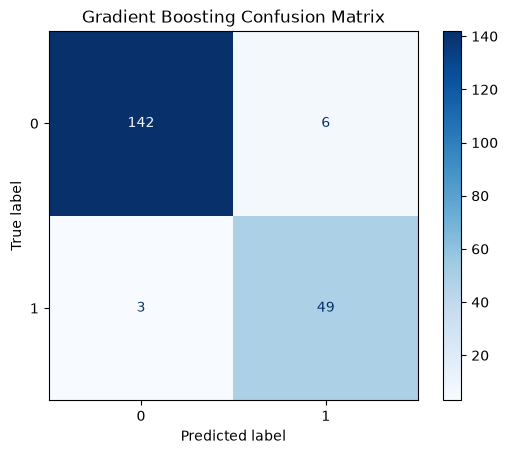

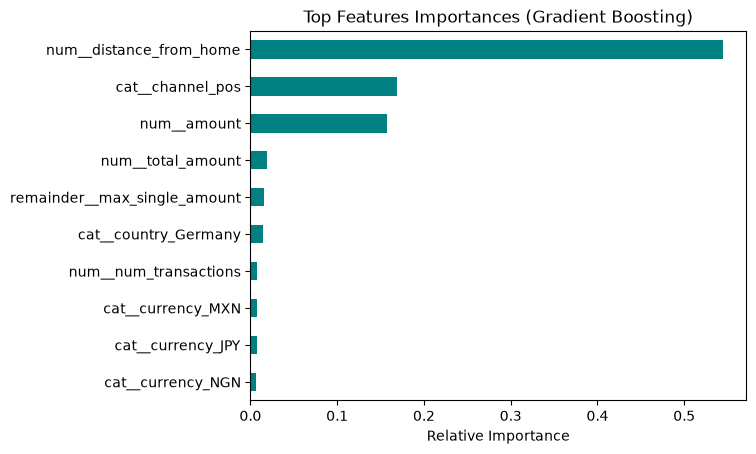

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay

# confustion matrix for gradient boosting
ConfusionMatrixDisplay.from_estimator(gb_model, X_test, y_test, cmap='Blues')
plt.title("Gradient Boosting Confusion Matrix")
plt.show()

# important features display
feature_importances = pd.Series(gb_model.feature_importances_, index=X_train.columns)
feature_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title("Top Features Importances (Gradient Boosting)")
plt.xlabel("Relative Importance")
plt.gca().invert_yaxis()
plt.show()